# 02 — Đánh giá bộ nhận diện: IoU, ghép khung, precision, recall, AP, mAP, ngưỡng F1

Bảng đầu tiên của README ghi "mAP50-95 = 0,413" cho bộ nhận diện COCO và 0,477 sau fine-tune.
Notebook này xây con số đó từ gốc: thế nào là "một dự đoán đúng", vì sao phải có quy tắc bỏ
qua, precision và recall đánh đổi nhau ra sao, và vì sao chỉ số cuối cùng lại lấy trung bình
qua mười ngưỡng IoU. Mọi phép tính chạy trên **dự đoán thật** của hai bộ nhận diện trong
`results/det/`.

*Số liệu trong notebook này lấy từ **phép chia cố định** (8 chuỗi test), dùng để minh hoạ khái niệm.
README báo kết quả của **kiểm định chéo 3 phần** trên cả 21 chuỗi (mAP50–95: 0,395 ± 0,061 với trọng
số COCO, 0,464 ± 0,024 sau fine-tune có NMS); notebook 05, mục 8 giải thích cách đó.*

| Mục | Câu hỏi |
|---|---|
| 1. IoU | Hai khung "trùng" nhau bao nhiêu? |
| 2. Ghép khung | Dự đoán nào đúng, dự đoán nào thừa? |
| 3. Quy tắc bỏ qua | Vì sao không phạt dự đoán "car" trên một xe van? |
| 4. Precision và recall | Đánh đổi giữa báo nhầm và bỏ sót |
| 5. AP | Gói cả đường precision–recall thành một số |
| 6. mAP50–95 | Vì sao trung bình qua mười ngưỡng IoU thưởng cho khung khít? |
| 7. Ngưỡng F1 | Chọn điểm hoạt động để đo khoảng cách |
| 8. Recall theo khoảng cách | Bộ nhận diện bỏ sót vật xa đến đâu? |

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from monodist import kitti, match
from monodist.detect import merge
from monodist.geometry import iou

ROOT = Path("../data/kitti_tracking")
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})

def load(config, split):
    det, _ = merge(f"../results/det/{config}")
    m = np.isin(det["seq"], kitti.SPLIT[split])
    return {k: v[m] for k, v in det.items()}

gt_test = match.ground_truth(ROOT, kitti.SPLIT["test"])
dets = {c: load(c, "test") for c in ("coco_1280", "ft_1280_nms")}
for c, d in dets.items():
    print(f"{c}: {len(d['score'])} detections with score >= 0.01 on the {len(gt_test)} test frames")

coco_1280: 85588 detections with score >= 0.01 on the 2186 test frames
ft_1280_nms: 37212 detections with score >= 0.01 on the 2186 test frames


## 1. IoU

**Định nghĩa.** Với hai khung $A$ và $B$:

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}.$$

**Ký hiệu mới**
- $|A|$: diện tích khung $A$ (pixel$^2$) · $A \cap B$: phần giao · $A \cup B$: phần hợp

IoU bằng 1 khi hai khung trùng khít, 0 khi không chạm nhau. Nó không phụ thuộc đơn vị, nhưng
**rất nhạy với khung nhỏ**: cùng lệch 2 pixel, một khung lớn gần như không đổi IoU, còn một
khung xa (nhỏ) mất nhiều.

In [2]:
for size in (200, 50, 20):
    a = np.array([[0, 0, size, size]])
    b = a + np.array([2, 2, 2, 2])            # the same box shifted by 2 px right and down
    print(f"{size:3d} px box shifted by 2 px: IoU = {iou(a, b)[0, 0]:.3f}")

200 px box shifted by 2 px: IoU = 0.961
 50 px box shifted by 2 px: IoU = 0.855
 20 px box shifted by 2 px: IoU = 0.681


Một chiếc xe ở 60 m chỉ cao khoảng 18 pixel (notebook 01), nên cùng một sai lệch nhỏ đã đủ
đẩy IoU xuống dưới ngưỡng chấm đúng. Đây là một lý do bộ nhận diện "bỏ sót" vật xa.

## 2. Ghép khung

Trong một khung hình, bộ nhận diện trả về nhiều dự đoán, mỗi cái có **điểm tin cậy**
(score). Nhãn có một số vật thật. Quy tắc ghép (theo cách chấm của COCO):

1. Xếp các dự đoán theo điểm **giảm dần**.
2. Lần lượt, mỗi dự đoán được ghép với vật thật **cùng lớp, chưa bị ghép**, có IoU lớn nhất,
   nếu IoU đó $\ge$ ngưỡng (0,5 là phổ biến nhất).
3. Dự đoán ghép được là **TP**; không ghép được là **FP**. Vật thật không ai ghép là **FN**.

**Ký hiệu mới**
- **TP** (true positive): đúng · **FP** (false positive): báo nhầm · **FN** (false negative): bỏ sót

Dự đoán thứ hai trên cùng một chiếc xe là FP, vì chiếc xe đã bị dự đoán điểm cao hơn "lấy"
mất. Đó là lý do bộ nhận diện cần NMS hoặc một đầu ra một-một (notebook 03).

In [3]:
key = ("0012", 0)
d = dets["coco_1280"]
m = (d["seq"] == key[0]) & (d["frame"] == key[1]) & (d["score"] >= 0.2)
status, idx = match.match_frame(d["box"][m], d["score"][m], d["cls"][m], gt_test[key], thresholds=[0.5])
names = {match.TP: "TP", match.FP: "FP", match.IGNORED: "ignored"}
for b, s, c, st, j in zip(d["box"][m], d["score"][m], d["cls"][m], status[:, 0], idx[:, 0]):
    best = iou(b, gt_test[key]["box"]).max() if len(gt_test[key]["box"]) else 0
    print(f"{kitti.CLASSES[c]:10s} score {s:.2f} box {np.round(b)} best IoU with a label {best:.2f} -> {names[st]}")
print("labelled objects in this frame:", [kitti.CLASSES[c] for c in gt_test[key]["cls"]])

Car        score 0.92 box [459. 182. 569. 215.] best IoU with a label 0.88 -> TP
Car        score 0.47 box [655. 181. 685. 206.] best IoU with a label 0.82 -> TP
Pedestrian score 0.45 box [580. 172. 631. 259.] best IoU with a label 0.00 -> FP
Car        score 0.32 box [715. 186. 732. 196.] best IoU with a label 0.00 -> ignored
Car        score 0.20 box [732. 182. 746. 196.] best IoU with a label 0.00 -> ignored
labelled objects in this frame: ['Car', 'Car']


Trong khung này: hai xe được ghép đúng. Dự đoán "Pedestrian" là **người đi xe đạp** (nhãn
Cyclist, không phải lớp của dự án) nên thành FP. Hai "Car" nhỏ nằm trong vùng DontCare nên bị
bỏ qua, như mục sau giải thích.

## 3. Quy tắc bỏ qua

Nhãn KITTI có ba loại vùng mà một dự đoán rơi vào thì **không nên bị phạt**:
- **Van** khi chấm lớp Car: một bộ nhận diện huấn luyện trên COCO không có lớp "van", nó gọi xe
  van là "car". Đó không phải lỗi.
- **Person** (người ngồi) khi chấm lớp Pedestrian, cùng lý do.
- **DontCare**: vùng có vật nhưng người gán nhãn bỏ qua. Dự đoán có ít nhất một nửa diện tích
  nằm trong vùng này bị bỏ qua.

Bộ công cụ chấm chính thức của KITTI (devkit) dùng đúng ba quy tắc này. Trạng thái "bỏ qua"
không tính là TP, cũng không là FP. Đếm trên tập test (điểm $\ge 0{,}25$, IoU 0,5):

In [4]:
for c, d in dets.items():
    st, _ = match.evaluate(d, gt_test, thresholds=[0.5])
    keep = d["score"] >= 0.25
    print(f"{c:12s} TP {np.sum(st[keep, 0] == match.TP):5d}  FP {np.sum(st[keep, 0] == match.FP):5d}  "
          f"ignored {np.sum(st[keep, 0] == match.IGNORED):5d}")

coco_1280    TP  6047  FP  1636  ignored  2274


ft_1280_nms  TP  6213  FP  1460  ignored  1775


Với bộ nhận diện COCO, số dự đoán bị bỏ qua đáng kể. Nếu không có quy tắc này, nó bị phạt vì
"nhìn thấy" xe van, một thứ nó đúng khi nhìn thấy. Quy tắc còn một hệ quả: người đi xe đạp
(Cyclist) **không** phải lớp lân cận của Pedestrian, nên khi COCO gọi người trên xe đạp là
"person" thì vẫn tính FP. Bộ nhận diện fine-tune học được cách không gọi họ là người đi bộ.

## 4. Precision và recall

**Định nghĩa**, với một ngưỡng điểm cho trước (chỉ giữ dự đoán có điểm $\ge$ ngưỡng):

$$\text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN} = \frac{TP}{N_{\text{vật}}}.$$

- **Precision**: trong những gì báo, bao nhiêu phần đúng.
- **Recall**: trong những vật có thật, tìm được bao nhiêu phần.

**Ký hiệu mới**
- $N_{\text{vật}}$: số vật thật của lớp đó trên toàn tập (= TP + FN)

Hạ ngưỡng thì giữ thêm dự đoán: recall tăng, precision thường giảm. Quét ngưỡng từ cao xuống
thấp được **đường precision–recall**. Một mẹo tính: xếp mọi dự đoán theo điểm giảm dần; sau
$k$ dự đoán đầu, $TP_k$ là tổng tích luỹ các TP, còn $FP_k = k - TP_k$ (dự đoán bị bỏ qua đã
loại ra từ trước).

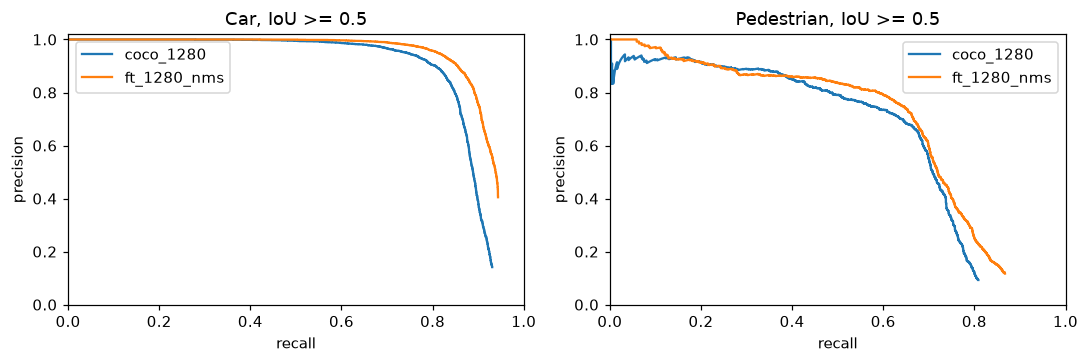

In [5]:
def pr_curve(d, gt, cls, col=0):
    st, _ = match.evaluate(d, gt)
    m = (d["cls"] == cls) & (st[:, col] != match.IGNORED)
    order = np.argsort(-d["score"][m], kind="stable")
    tp = (st[m, col] == match.TP)[order]
    n = sum((g["cls"] == cls).sum() for g in gt.values())
    ctp = np.cumsum(tp)
    return ctp / n, ctp / np.arange(1, len(tp) + 1), d["score"][m][order], st, n

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
curves = {}
for c, d in dets.items():
    for cls, ax in zip((0, 1), axes):
        rec, prec, _, st, n = pr_curve(d, gt_test, cls)
        curves[(c, cls)] = (rec, prec, st, n)
        ax.plot(rec, prec, label=c)
for cls, ax in zip((0, 1), axes):
    ax.set_title(f"{kitti.CLASSES[cls]}, IoU >= 0.5"); ax.set_xlabel("recall"); ax.set_ylabel("precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend()
plt.tight_layout(); plt.show()

## 5. AP: gói đường precision–recall thành một số

**Định nghĩa.** AP (average precision) là diện tích dưới đường precision–recall. Đường thật
răng cưa (mỗi FP làm precision tụt), nên trước khi tính, COCO thay precision tại mỗi mức
recall bằng **precision lớn nhất đạt được ở mức recall đó hoặc cao hơn** (đường bao). Rồi lấy
giá trị tại 101 mức recall cách đều:

$$\text{AP} = \frac{1}{101}\sum_{r \in \{0;\,0{,}01;\,\dots;\,1\}} \;\max_{r' \ge r} \text{precision}(r').$$

Mức recall không bao giờ đạt được góp 0. Tính lại và so với hàm `match.average_precision` mà
dự án dùng:

In [6]:
def ap_by_hand(rec, prec):
    env = np.maximum.accumulate(prec[::-1])[::-1]           # best precision at this recall or higher
    return np.mean([env[np.searchsorted(rec, r)] if np.searchsorted(rec, r) < len(env) else 0.0
                    for r in np.linspace(0, 1, 101)])

for (c, cls), (rec, prec, st, n) in curves.items():
    m = dets[c]["cls"] == cls
    ref = match.average_precision(dets[c]["score"][m], st[m, 0], n)
    print(f"{c:12s} {kitti.CLASSES[cls]:10s} AP50 by hand {ap_by_hand(rec, prec):.4f} | project {ref:.4f}")

coco_1280    Car        AP50 by hand 0.8699 | project 0.8699
coco_1280    Pedestrian AP50 by hand 0.6223 | project 0.6223
ft_1280_nms  Car        AP50 by hand 0.9093 | project 0.9093
ft_1280_nms  Pedestrian AP50 by hand 0.6586 | project 0.6586


## 6. mAP50–95: trung bình qua mười ngưỡng IoU

AP ở ngưỡng IoU 0,5 (AP50) chỉ hỏi "khung có đúng chỗ không". COCO hỏi thêm "khung có khít
không" bằng cách tính AP ở mười ngưỡng $0{,}50;\,0{,}55;\,\dots;\,0{,}95$ rồi lấy trung bình,
sau đó trung bình tiếp qua các lớp:

$$\text{mAP}_{50\text{–}95} = \frac{1}{|\mathcal C|}\sum_{c \in \mathcal C}\;\frac{1}{10}\sum_{t \in \{0{,}50,\dots,0{,}95\}} \text{AP}_c(t).$$

**Ký hiệu mới**
- $\mathcal C$: tập các lớp (ở đây Car và Pedestrian) · $t$: ngưỡng IoU

Ở ngưỡng 0,95 khung phải gần như trùng khít. Vì vậy mAP50–95 thưởng cho **khung khít**, đúng
thứ công thức kích thước ở notebook 01 cần. Xem AP của từng ngưỡng:

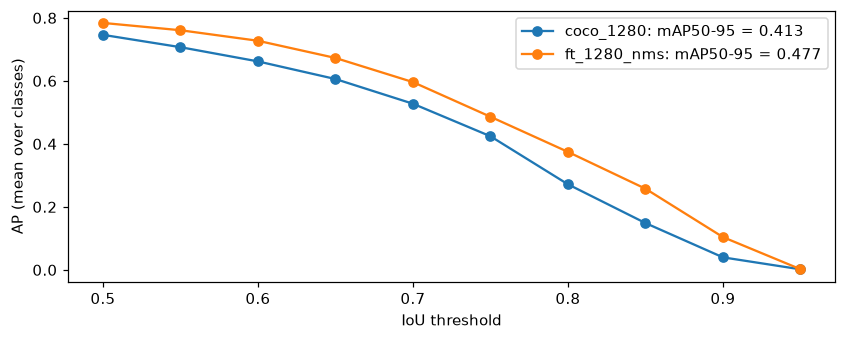

In [7]:
for c, d in dets.items():
    st, _ = match.evaluate(d, gt_test)
    rep = match.detection_report(d, gt_test, st)
    aps = []
    for t in range(len(match.IOU_THRESHOLDS)):
        per_cls = []
        for cls in (0, 1):
            m = d["cls"] == cls
            per_cls.append(match.average_precision(d["score"][m], st[m, t], rep[kitti.CLASSES[cls]]["n_gt"]))
        aps.append(np.mean(per_cls))
    plt.plot(match.IOU_THRESHOLDS, aps, marker="o", label=f"{c}: mAP50-95 = {rep['mAP50-95']:.3f}")
plt.xlabel("IoU threshold"); plt.ylabel("AP (mean over classes)"); plt.legend(); plt.show()

Ở IoU 0,5 hai bộ nhận diện cách nhau 3,8 điểm AP (0,746 so với 0,784); ở IoU 0,7 là 6,9 điểm
(0,527 so với 0,596); ở IoU 0,9 bản fine-tune gấp 2,6 lần (0,104 so với 0,040); đến 0,95 cả hai
gần 0. Nghĩa là fine-tune tìm thêm được ít vật, nhưng làm khung **khít với nhãn KITTI** hơn
hẳn. Chính vì khít với nhãn hơn nên khung ô tô ôm trọn chiều dài xe hơn, và công thức kích
thước tệ đi (notebook 01, mục 3).

**Kiểm chứng độc lập.** Trên tập val, bỏ quy tắc bỏ qua, dùng NMS, bộ chấm của dự án cho
mAP50–95 = 0,466; công cụ validation của Ultralytics cho 0,465 trên cùng trọng số. Hai bộ
chấm độc lập khớp nhau tới 0,001.

## 7. Điểm hoạt động: ngưỡng F1

AP tính trên *mọi* ngưỡng, nhưng khi đo khoảng cách phải chọn *một* ngưỡng để giữ dự đoán.
Ngưỡng cố định 0,25 (mặc định của YOLO) không công bằng: bộ nhận diện nào trả điểm cao hơn thì
được lợi. Dự án chọn, cho mỗi bộ nhận diện và mỗi lớp, ngưỡng làm **F1** lớn nhất trên **tập val**:

$$F_1 = \frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}} = \frac{2\,TP}{2\,TP + FP + FN}.$$

F1 là **trung bình điều hoà** của precision và recall. Nó thấp nếu một trong hai thấp, nên cực
đại của nó cân bằng giữa báo nhầm và bỏ sót.

In [8]:
gt_val = match.ground_truth(ROOT, kitti.SPLIT["val"])
for c in dets:
    d = load(c, "val")
    for cls in (0, 1):
        rec, prec, score, st, n = pr_curve(d, gt_val, cls)
        f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
        i = int(np.argmax(f1))
        m = d["cls"] == cls
        ref = match.f1_threshold(d["score"][m], st[m, 0], n)
        print(f"{c:12s} {kitti.CLASSES[cls]:10s} best F1 {f1[i]:.3f} at score {score[i]:.3f} "
              f"(precision {prec[i]:.2f}, recall {rec[i]:.2f}) | project threshold {ref:.3f}")

coco_1280    Car        best F1 0.771 at score 0.274 (precision 0.85, recall 0.70) | project threshold 0.274


coco_1280    Pedestrian best F1 0.703 at score 0.337 (precision 0.76, recall 0.66) | project threshold 0.337


ft_1280_nms  Car        best F1 0.829 at score 0.327 (precision 0.92, recall 0.75) | project threshold 0.327


ft_1280_nms  Pedestrian best F1 0.700 at score 0.335 (precision 0.76, recall 0.65) | project threshold 0.335


## 8. Recall theo khoảng cách

Ở điểm hoạt động vừa chọn, bao nhiêu phần vật thật được tìm thấy, theo từng dải khoảng cách?

In [9]:
import json
for c in dets:
    r = json.loads(Path(f"../results/eval/{c}.json").read_text())["recall_by_distance"]
    for cls in kitti.CLASSES:
        cells = " ".join(f"{f / t:5.0%} ({int(t):4d})" for f, t in zip(r[cls]["found"], r[cls]["total"]))
        print(f"{c:12s} {cls:10s} 0-10 / 10-20 / 20-40 / >40 m: {cells}")

coco_1280    Car        0-10 / 10-20 / 20-40 / >40 m:   94% ( 995)   94% ( 951)   85% (2096)   63% (1592)
coco_1280    Pedestrian 0-10 / 10-20 / 20-40 / >40 m:   83% ( 579)   72% ( 944)   42% ( 420)    7% (  76)
ft_1280_nms  Car        0-10 / 10-20 / 20-40 / >40 m:   98% ( 995)   98% ( 951)   93% (2096)   53% (1592)
ft_1280_nms  Pedestrian 0-10 / 10-20 / 20-40 / >40 m:   89% ( 579)   72% ( 944)   26% ( 420)    0% (  76)


Vật xa là điểm yếu chung: trên 40 m chỉ còn khoảng hai phần ba số ô tô và gần như không người
đi bộ nào. Hai lý do đã gặp ở trên: khung nhỏ nên IoU nhạy (mục 1), và ở độ phân giải đầu vào
1280 một người ở 50 m chỉ cao khoảng 25 pixel. Sai số khoảng cách của dự án vì vậy chỉ đo được
trên những vật **đã được tìm thấy**; notebook 05 bàn cách so sánh hai bộ nhận diện cho công bằng
khi chúng tìm thấy những tập vật khác nhau.

## Tóm tắt

- IoU = giao / hợp; nhạy với khung nhỏ, nên vật xa khó được chấm đúng.
- Ghép tham lam theo điểm: TP, FP, FN; dự đoán trùng là FP; Van, Person và DontCare bị bỏ qua như devkit KITTI.
- AP = diện tích dưới đường bao precision–recall, lấy mẫu ở 101 mức recall; mAP50–95 lấy trung
  bình qua mười ngưỡng IoU nên thưởng cho khung khít. Bộ chấm của dự án khớp Ultralytics (0,466 so với 0,465).
- Fine-tune chủ yếu làm khung khít hơn chứ không tìm thêm vật; khung khít với nhãn lại làm công thức kích thước tệ đi.
- Điểm hoạt động: ngưỡng F1 tốt nhất trên val, riêng cho từng bộ nhận diện và từng lớp.